# Project 2 - Student Performance Analysis

**Domain:** Education  
**Objective:** Analyse pass/fail rates, subject performance, attendance impact, and student risk.

## 1. Setup and data loading

In [1]:
from pathlib import Path
import sys, pandas as pd, numpy as np
ROOT=Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
from src.student_analysis import SUBJECTS, validate_student_data, clean_student_data, calculate_student_kpis
raw=pd.read_csv(ROOT/'data/project2_students/student_performance_raw.csv')
raw.head()

,student_id,school,grade,section,gender,age,attendance_pct,study_hours_daily,internet_access,parent_education,mathematics,science,english,social_science,computer
0,STU-0001,West Senior,10,A,Male,16,66.5,1.0,Yes,Graduate,54.0,42.5,54.2,55.8,56.2
1,STU-0002,South Public,9,B,Female,14,78.4,4.2,Yes,Graduate,88.5,67.6,83.5,84.1,84.9
2,STU-0003,East Model,9,C,Female,14,58.3,4.8,Yes,Primary,70.9,64.9,65.4,72.6,71.1
3,STU-0004,East Model,11,A,Male,16,92.4,4.2,Yes,Secondary,81.4,83.7,83.5,60.0,71.9
4,STU-0005,South Public,10,C,Male,15,69.9,2.7,Yes,Primary,56.0,58.8,62.0,58.8,64.4


## 2. Validation and cleaning

In [2]:
raw_validation=validate_student_data(raw)
pd.Series(raw_validation)

rows                                                                     1202
columns                                                                    15
missing_required_columns                                                   []
duplicate_student_ids                                                       2
missing_values              {'attendance_pct': 1, 'mathematics': 1, 'scien...
invalid_score_values                                                        0
invalid_attendance_rows                                                     0
invalid_study_hours_rows                                                    0
dtype: object

In [3]:
students=clean_student_data(raw)
print(f'{len(raw):,} raw rows -> {len(students):,} clean students')
validate_student_data(students)

1,202 raw rows -> 1,200 clean students


{'rows': 1200,
 'columns': 21,
 'missing_required_columns': [],
 'duplicate_student_ids': 0,
 'missing_values': {},
 'invalid_score_values': 0,
 'invalid_attendance_rows': 0,
 'invalid_study_hours_rows': 0}

## 3. Descriptive statistics and KPIs

In [4]:
kpis=calculate_student_kpis(students)
pd.Series(kpis).to_frame('Value')

,Value
students,1200
overall_average,66.49
overall_median,66.18
overall_pass_rate_pct,93.83
at_risk_students,321
at_risk_rate_pct,26.75
average_attendance_pct,81.72
top_subject,Computer
top_subject_average,69.79
lowest_subject,Mathematics


In [5]:
students[['attendance_pct','study_hours_daily',*SUBJECTS,'average_score']].describe().round(2)

,attendance_pct,study_hours_daily,mathematics,science,english,social_science,computer,average_score
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,81.72,2.28,62.43,64.58,68.72,66.93,69.79,66.49
std,9.81,1.36,11.99,12.03,11.74,12.04,11.75,8.00
min,45.00,0.20,27.00,26.10,34.50,33.10,37.00,39.20
25%,75.00,1.30,54.28,56.70,61.20,58.80,61.58,61.06
50%,81.80,2.00,62.05,64.35,68.30,66.60,69.70,66.18
75%,88.60,3.00,70.40,72.60,76.40,75.12,77.70,71.53
max,100.00,7.00,100.00,100.00,100.00,100.00,100.00,97.24


## 4. Subject and pass/fail analysis

In [6]:
subject_summary=pd.DataFrame({'average':students[SUBJECTS].mean(),'median':students[SUBJECTS].median(),'pass_rate_pct':students[SUBJECTS].ge(40).mean()*100}).round(2)
subject_summary

,average,median,pass_rate_pct
mathematics,62.43,62.05,97.58
science,64.58,64.35,98.17
english,68.72,68.30,98.92
social_science,66.93,66.60,98.67
computer,69.79,69.70,99.75


In [7]:
students['result'].value_counts().to_frame('students').assign(rate_pct=lambda x:x.students/len(students)*100).round(2)

,students,rate_pct
result,,
Pass,1126,93.83
Fail,74,6.17


## 5. Attendance, study habits, and subgroup analysis

In [8]:
students.groupby(pd.cut(students.attendance_pct,[0,60,75,85,100]))['average_score'].agg(['count','mean','median']).round(2)

,count,mean,median
attendance_pct,,,
"(0, 60]",28,56.31,54.61
"(60, 75]",275,61.94,61.06
"(75, 85]",443,66.33,66.32
"(85, 100]",454,70.03,69.70


In [9]:
students.groupby(['grade','gender']).agg(students=('student_id','count'),average_score=('average_score','mean'),pass_rate=('result',lambda s:(s=='Pass').mean()*100)).round(2)

students  average_score  pass_rate
grade gender                                    
9     Female       170          67.74      96.47
      Male         130          68.13      94.62
10    Female       146          66.75      95.21
      Male         150          65.93      91.33
11    Female       159          65.33      93.08
      Male         145          66.55      95.86
12    Female       155          65.48      90.97
      Male         145          66.17      93.10

## 6. Correlation analysis
Pearson correlation describes linear association and does not prove causality.

In [10]:
students[['attendance_pct','study_hours_daily',*SUBJECTS,'average_score']].corr().round(3)

,attendance_pct,study_hours_daily,mathematics,science,english,social_science,computer,average_score
attendance_pct,1.000,-0.004,0.302,0.301,0.293,0.319,0.310,0.454
study_hours_daily,-0.004,1.000,0.449,0.474,0.460,0.441,0.451,0.677
mathematics,0.302,0.449,1.000,0.324,0.317,0.272,0.298,0.660
science,0.301,0.474,0.324,1.000,0.330,0.317,0.306,0.680
english,0.293,0.460,0.317,0.330,1.000,0.304,0.322,0.674
social_science,0.319,0.441,0.272,0.317,0.304,1.000,0.348,0.669
computer,0.310,0.451,0.298,0.306,0.322,0.348,1.000,0.675
average_score,0.454,0.677,0.660,0.680,0.674,0.669,0.675,1.000


## 7. At-risk students

In [11]:
risk=students[students.at_risk=='Yes'][['student_id','grade','attendance_pct','average_score','subjects_passed','result']]
risk.head(15)

,student_id,grade,attendance_pct,average_score,subjects_passed,result
0,STU-0001,10,66.5,52.54,5,Pass
2,STU-0003,9,58.3,68.98,5,Pass
4,STU-0005,10,69.9,60.00,5,Pass
8,STU-0009,10,73.4,60.60,5,Pass
12,STU-0013,12,73.4,65.94,5,Pass
13,STU-0014,9,67.9,55.32,4,Fail
15,STU-0016,10,73.4,61.76,5,Pass
17,STU-0018,11,66.2,59.34,5,Pass
20,STU-0021,11,68.5,48.56,5,Pass
22,STU-0023,9,74.1,70.66,5,Pass


## 8. Visualizations

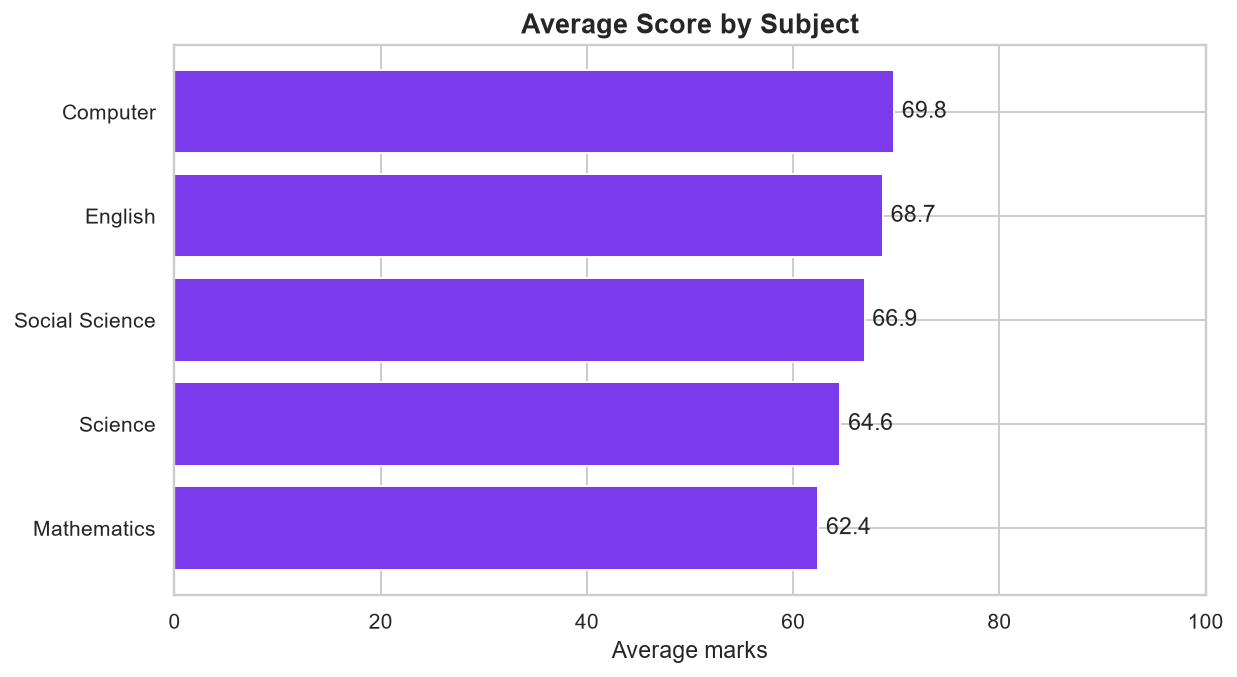

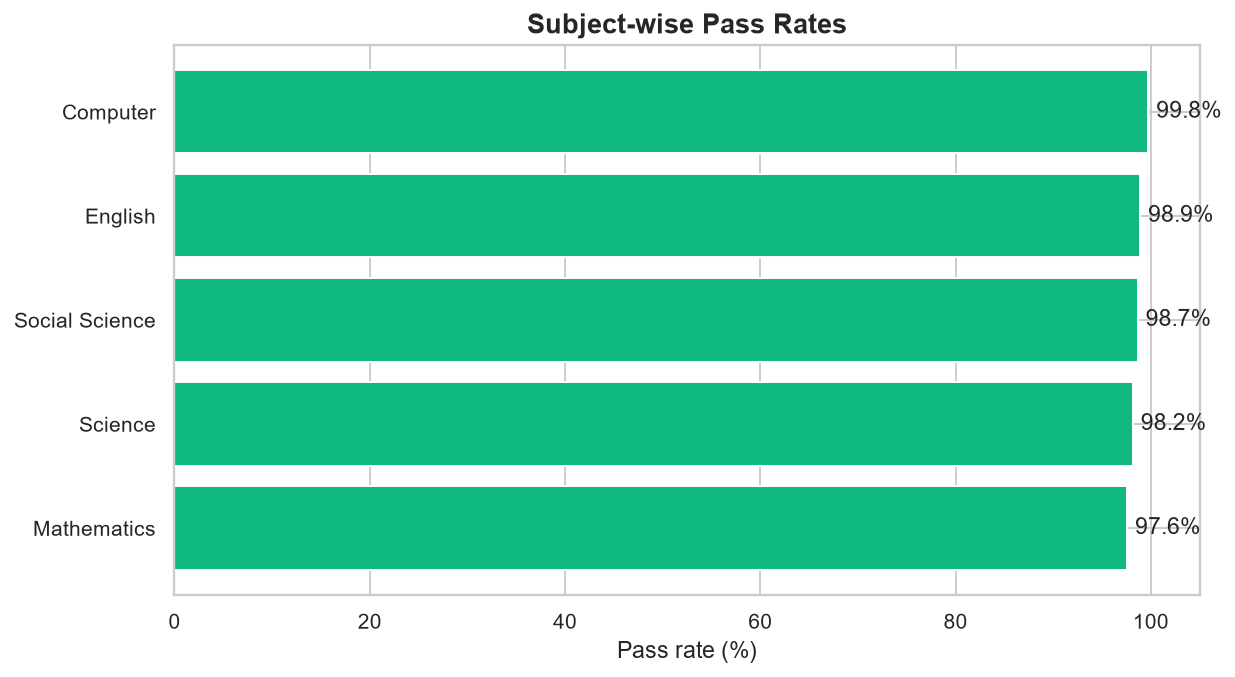

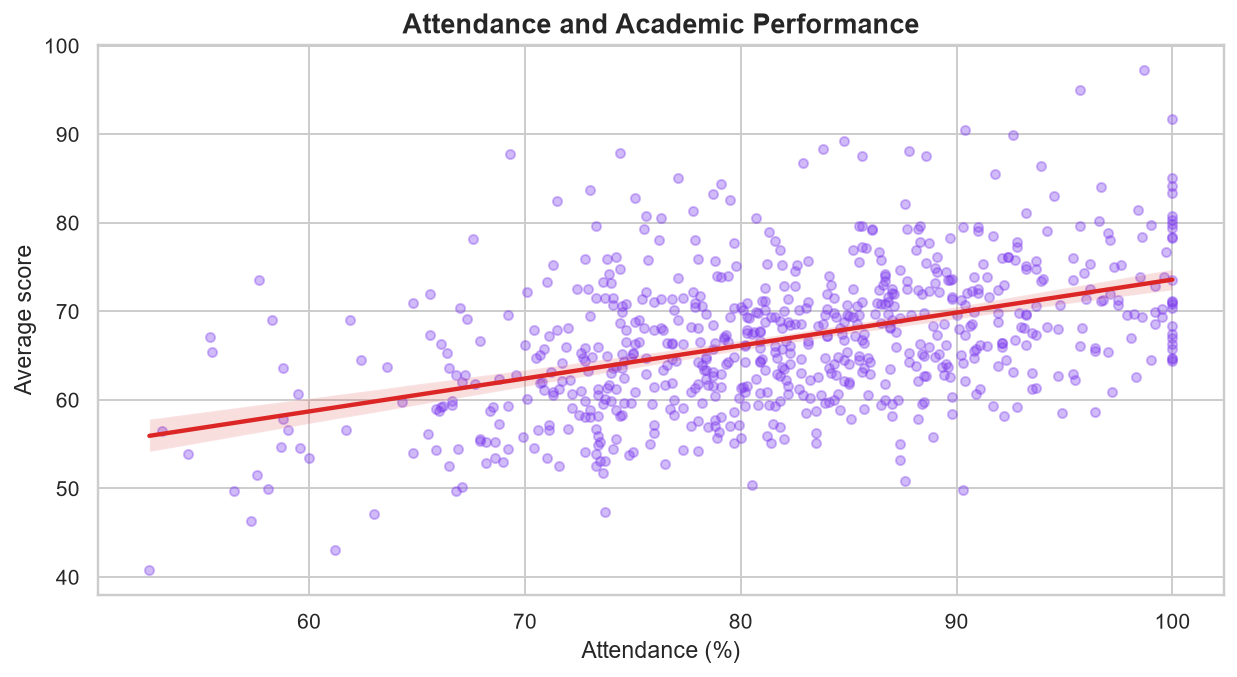

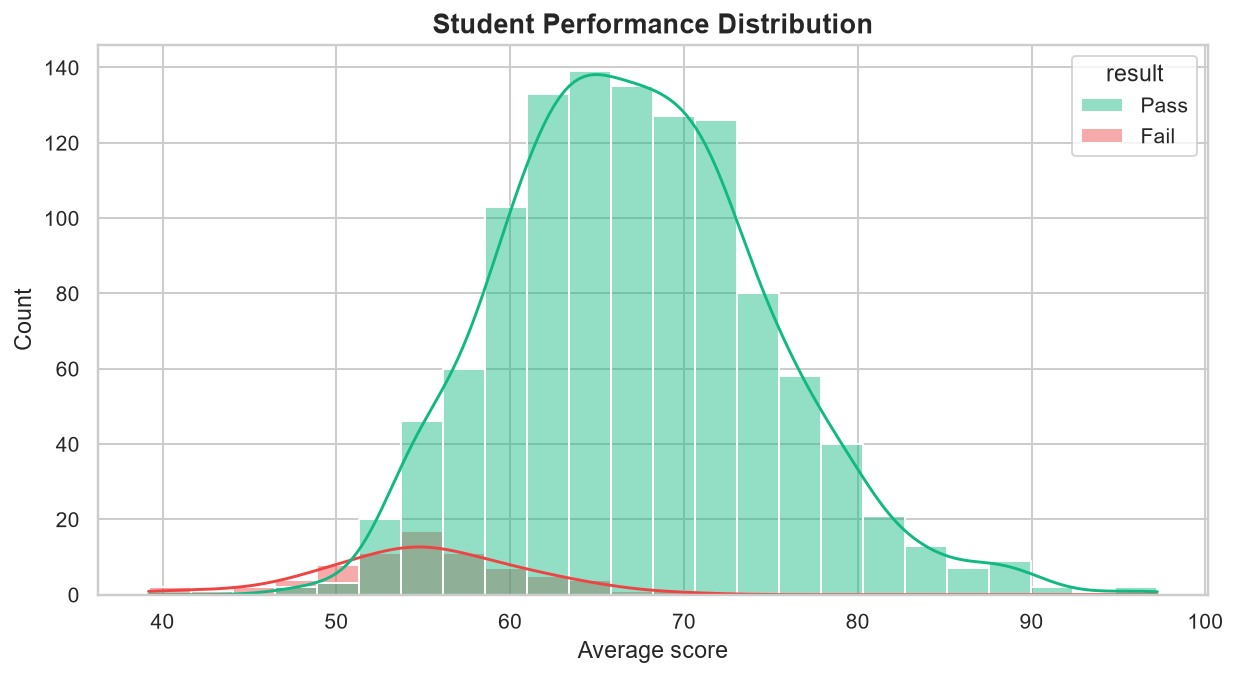

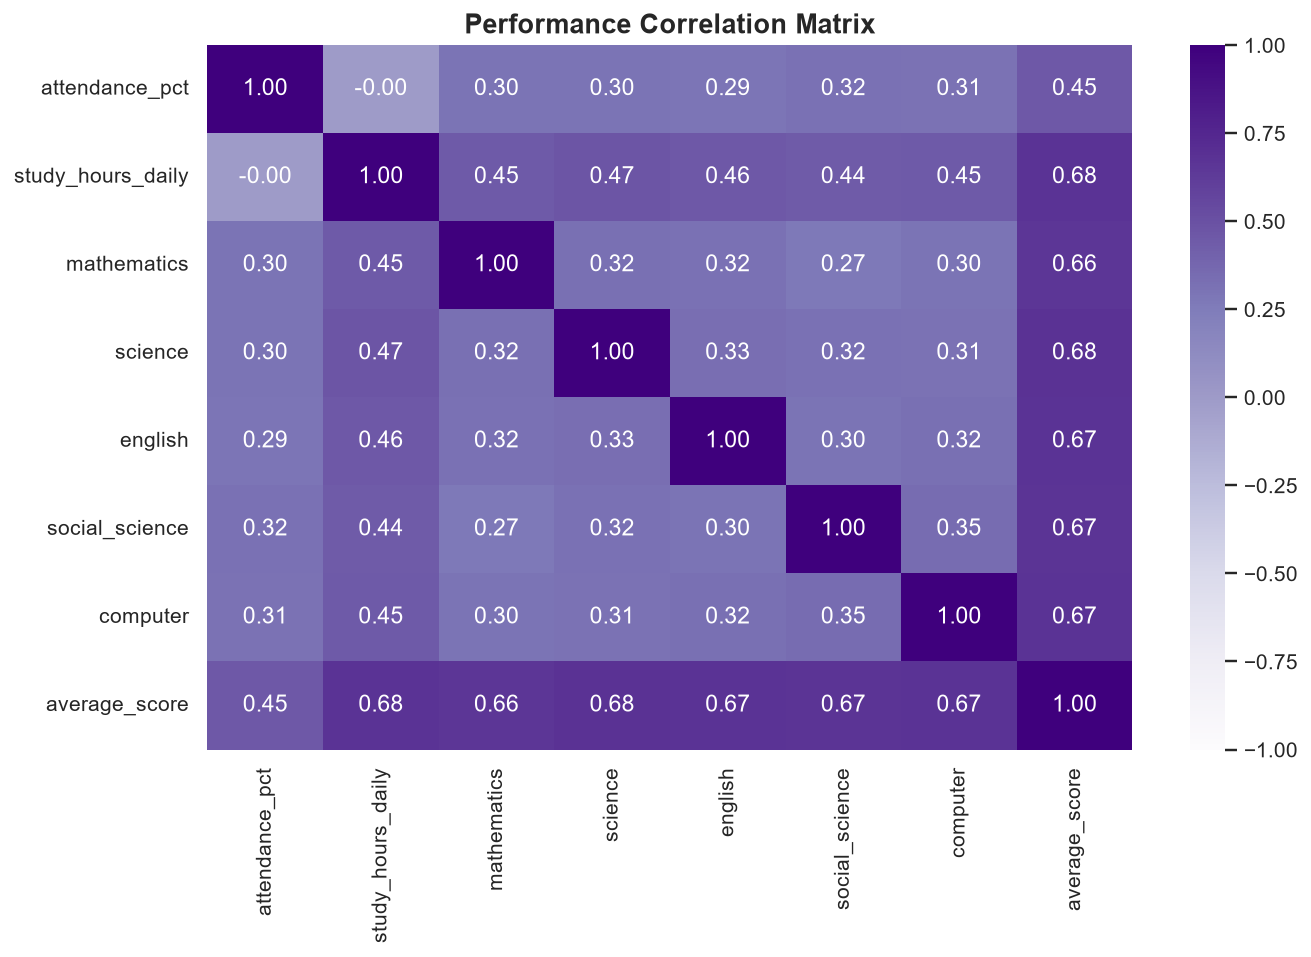

In [12]:
from IPython.display import display, Image
for chart in sorted((ROOT/'visualizations/project2_students').glob('*.png')):
    display(Image(filename=str(chart),width=850))

## 9. Recommendations
1. Use attendance alerts before students fall below 75%.
2. Provide subject-specific tutoring based on failed subjects.
3. Review at-risk progress every two weeks.
4. Provide supervised digital access where needed.
5. Measure pass conversion and risk-exit rates.

## 10. Ethical note
Risk flags should support teachers, not replace judgement or penalise students. No real personal data is used in this simulated portfolio project.